In [27]:
import importlib
import sys
sys.path.insert(0, "/home/claude")
from datetime import datetime
import pandas as pd
import networkx as nx
import visualize_ean as viz
from build_ean import build_ean, add_headway_arcs, propagate, enrich_trip_data_with_boundaries
import headway_integration_copy as hi
import numpy as np
importlib.reload(viz)
importlib.reload(hi)

<module 'headway_integration_copy' from 'c:\\Users\\LeoC\\VSCodes\\optimizationVinschgau\\SimulatedAnnealing\\infrastructuredesign\\EAN\\headway_integration_copy.py'>

In [28]:
'''    3: [("D", D(8, 10), D(8, 10)),
        ("C", D(8, 25), D(8, 26)),
        ("A", D(8, 40), D(8, 40))],

3: ["D", "Dev_D", "C", "Pr_C", "Dev_B", "MID", "Dev_A", "A"],'''

'    3: [("D", D(8, 10), D(8, 10)),\n        ("C", D(8, 25), D(8, 26)),\n        ("A", D(8, 40), D(8, 40))],\n\n3: ["D", "Dev_D", "C", "Pr_C", "Dev_B", "MID", "Dev_A", "A"],'

In [29]:
"""
Small synthetic line to sanity-check the pipeline before touching real data.

Layout (single track with one passing loop at MID):
  A --- Dev_A --- MID --- Dev_B --- B
pk_rel: 0        2        5        8       10

Two trains: 1 runs A->B ('down'), 2 runs B->A ('up'), both 'slow'
(pretend classification, override via monkeypatch below since we have no
real stop_slow/stop_fast columns configured to test the heuristic itself
-- that part is tested separately).
"""


D = lambda h, m, s=0: datetime(1900, 1, 1, h, m, s)

trip_data = {
    1: [("A", D(7, 30), D(7, 30)),
        ("B", D(7, 45), D(7,46)),
        ("D", D(8, 5), D(8, 5))],
    2: [("D", D(7, 35), D(7, 35)),
        ("C", D(7, 40), D(7, 42)),
        ("MID", D(7, 55), D(7, 57)),
        ("A", D(8, 5), D(8, 5))],

    3: [("A", D(8, 45), D(8, 45)),
        ("B", D(8, 55), D(8,55)),
        ("D", D(9, 5), D(9, 5))],
}

trip_data = {
    train_id: [
        (station, arr_dt, dep_dt, True)
        for station, arr_dt, dep_dt in stops
    ]
    for train_id, stops in trip_data.items()
}

routes = {
    1: ["A", "Dev_A", "MID", "Dev_B", "Pr_B", "B", "Dev_D", "D"],
    2: ["D", "Dev_D", "C", "Pr_C", "Dev_B", "MID", "Dev_A", "A"],
    
    3: ["A", "Dev_A", "MID", "Dev_B", "Pr_B", "B", "Dev_D", "D"]
}

nodesDf = pd.DataFrame({
    "pk_rel": [0, 2, 5, 8, 10, 9, 9, 10, 12, 14],
    "stop_slow": [1, 0, 1, 0, 1, 0, 0, 1, 0, 1],
    "stop_fast": [1, 0, 0, 0, 1, 0, 0, 1, 0, 1],
    "node_type": ["LdS", "dev", "LdS", "dev", "LdS", "pr", "pr", "LdS", "dev", "LdS"]
}, index=["A", "Dev_A", "MID", "Dev_B", "B", "Pr_B", "Pr_C", "C", "Dev_D", "D"])

edgesDf = pd.DataFrame({
    "node_from": ["A", "Dev_A", "MID", "Dev_B", "Dev_B", "Pr_B", "Pr_C", "C", "B", "Dev_D"],
    "node_to":   ["Dev_A", "MID", "Dev_B", "Pr_B", "B", "Pr_C", "C", "Dev_D", "Dev_D", "D"],
}, index=["e1", "e2", "e3", "e4", "e5", "e6", "e7", "e8", "e9", "e10"])

edgesDf["length"] = (edgesDf["node_to"].map(nodesDf["pk_rel"])- edgesDf["node_from"].map(nodesDf["pk_rel"])).abs()

# --- 1. chain extraction ---
IG = hi.build_infra_graph(edgesDf)
chains, boundaries = hi.extract_chains(IG, nodesDf)
print("Chains:", chains)
assert ("A", "Dev_B") in chains or ("Dev_B", "A") in chains, "single chain A<->B expected (MID has degree 2, not a boundary)"

trip_data_enriched = enrich_trip_data_with_boundaries(trip_data, routes, nodesDf, chains)

# --- 2. direction ---
d1 = hi.train_direction(routes[1], nodesDf)
d2 = hi.train_direction(routes[2], nodesDf)
d3 = hi.train_direction(routes[3], nodesDf)
print("train 1 direction:", d1, "| train 2 direction:", d2, "| train 3 direction:", d3)
assert d1 != d2

# --- 3. speed category heuristic ---
cat1 = hi.train_speed_category(1, routes[1], trip_data, nodesDf)
print("train 1 speed category (heuristic):", cat1)
# train 1 stops at A and B only, skips MID which is stop_slow=1/stop_fast=0 -> should be 'fast'
assert cat1 == "fast"

cat2 = hi.train_speed_category(2, routes[2], trip_data, nodesDf)
print("train 2 speed category (heuristic):", cat2)
# train 2 stops at B and A only, skips MID which is stop_slow=1/stop_fast=1 -> should be 'slow'
assert cat2 == "slow"

cat3 = hi.train_speed_category(3, routes[3], trip_data, nodesDf)
print("train 3 speed category (heuristic):", cat3)
# train 3 stops at B and A only, skips MID which is stop_slow=1/stop_fast=0 -> should be 'fast'
assert cat3 == "fast"


# --- 4. chain boundary -> EAN event mapping ---
ev = hi.chain_boundary_event(1, routes[1], trip_data, "A", "entry")
print("entry event for train 1 at A:", ev)
assert ev == (0, "dep")
ev2 = hi.chain_boundary_event(1, routes[1], trip_data, "B", "exit")
print("exit event for train 1 at B:", ev2)
assert ev2 == (1, "arr")

# --- 5. full pipeline ---

headway_dict = {
    (("A", "Dev_B"), "fast up", "slow down"): 0.0,
    (("Dev_B", "Dev_D"), "fast up", "slow down"): 0.0,
    (("A", "Dev_B"), "slow down", "fast up"): 0.0,
    (("Dev_B", "Dev_D"), "slow down", "fast up"): 0.0,
    (("Dev_D", "D"), "fast down", "slow up"): 500.0,
    (("Dev_D", "D"), "slow down", "fast up"): 500.0,
}
'''# make sure chain key orientation matches whatever extract_chains produced
resolved_key = list(chains.keys())[0]
headway_dict = {
    (resolved_key, "fast up", "fast down"): 1000.0,
    (resolved_key, "fast up", "fast down"): 200.0,
}'''

constraints, skipped = hi.assemble_headway_constraints(trip_data, trip_data_enriched, routes, nodesDf, chains, headway_dict)
print("Constraints:", constraints)
print("Skipped:", skipped)
#assert len(constraints) == 1, f"expected 1 headway arc between the 2 trains, got {len(constraints)}"

G_scheduled = build_ean(trip_data_enriched)
G_scheduled = add_headway_arcs(G_scheduled, constraints)
assert nx.is_directed_acyclic_graph(G_scheduled), "graph must stay a DAG"

realized = propagate(G_scheduled, {})
print("Baseline propagation OK, DAG confirmed, no exceptions.")
print("ALL SYNTHETIC TESTS PASSED")

Chains: {('Dev_B', 'Dev_D'): ['Dev_B', 'B', 'Dev_D'], ('Dev_D', 'D'): ['Dev_D', 'D'], ('A', 'Dev_B'): ['A', 'Dev_A', 'MID', 'Dev_B']}
train 1 direction: up | train 2 direction: down | train 3 direction: up
train 1 speed category (heuristic): fast
train 2 speed category (heuristic): slow
train 3 speed category (heuristic): fast
entry event for train 1 at A: (0, 'dep')
exit event for train 1 at B: (1, 'arr')
[assemble_headway_constraints] 2 entries skipped -- inspect `skipped` for details (unmatched chains/categories).
Constraints: [{'train_i': 2, 'seq_i': 1, 'event_i': 'arr', 'train_j': 1, 'seq_j': 3, 'event_j': 'dep', 'min_headway': 500.0, 'resource': ('Dev_D', 'D')}, {'train_i': 2, 'seq_i': 3, 'event_i': 'arr', 'train_j': 1, 'seq_j': 1, 'event_j': 'dep', 'min_headway': 0.0, 'resource': ('Dev_B', 'Dev_D')}, {'train_i': 1, 'seq_i': 1, 'event_i': 'arr', 'train_j': 2, 'seq_j': 3, 'event_j': 'dep', 'min_headway': 0.0, 'resource': ('A', 'Dev_B')}, {'train_i': 2, 'seq_i': 5, 'event_i': 'arr'

In [30]:
from pprint import pprint
pprint(skipped)

[('category pair missing', ('Dev_D', 'D'), 'fast up', 'fast up'),
 ('category pair missing', ('Dev_B', 'Dev_D'), 'fast up', 'fast up')]


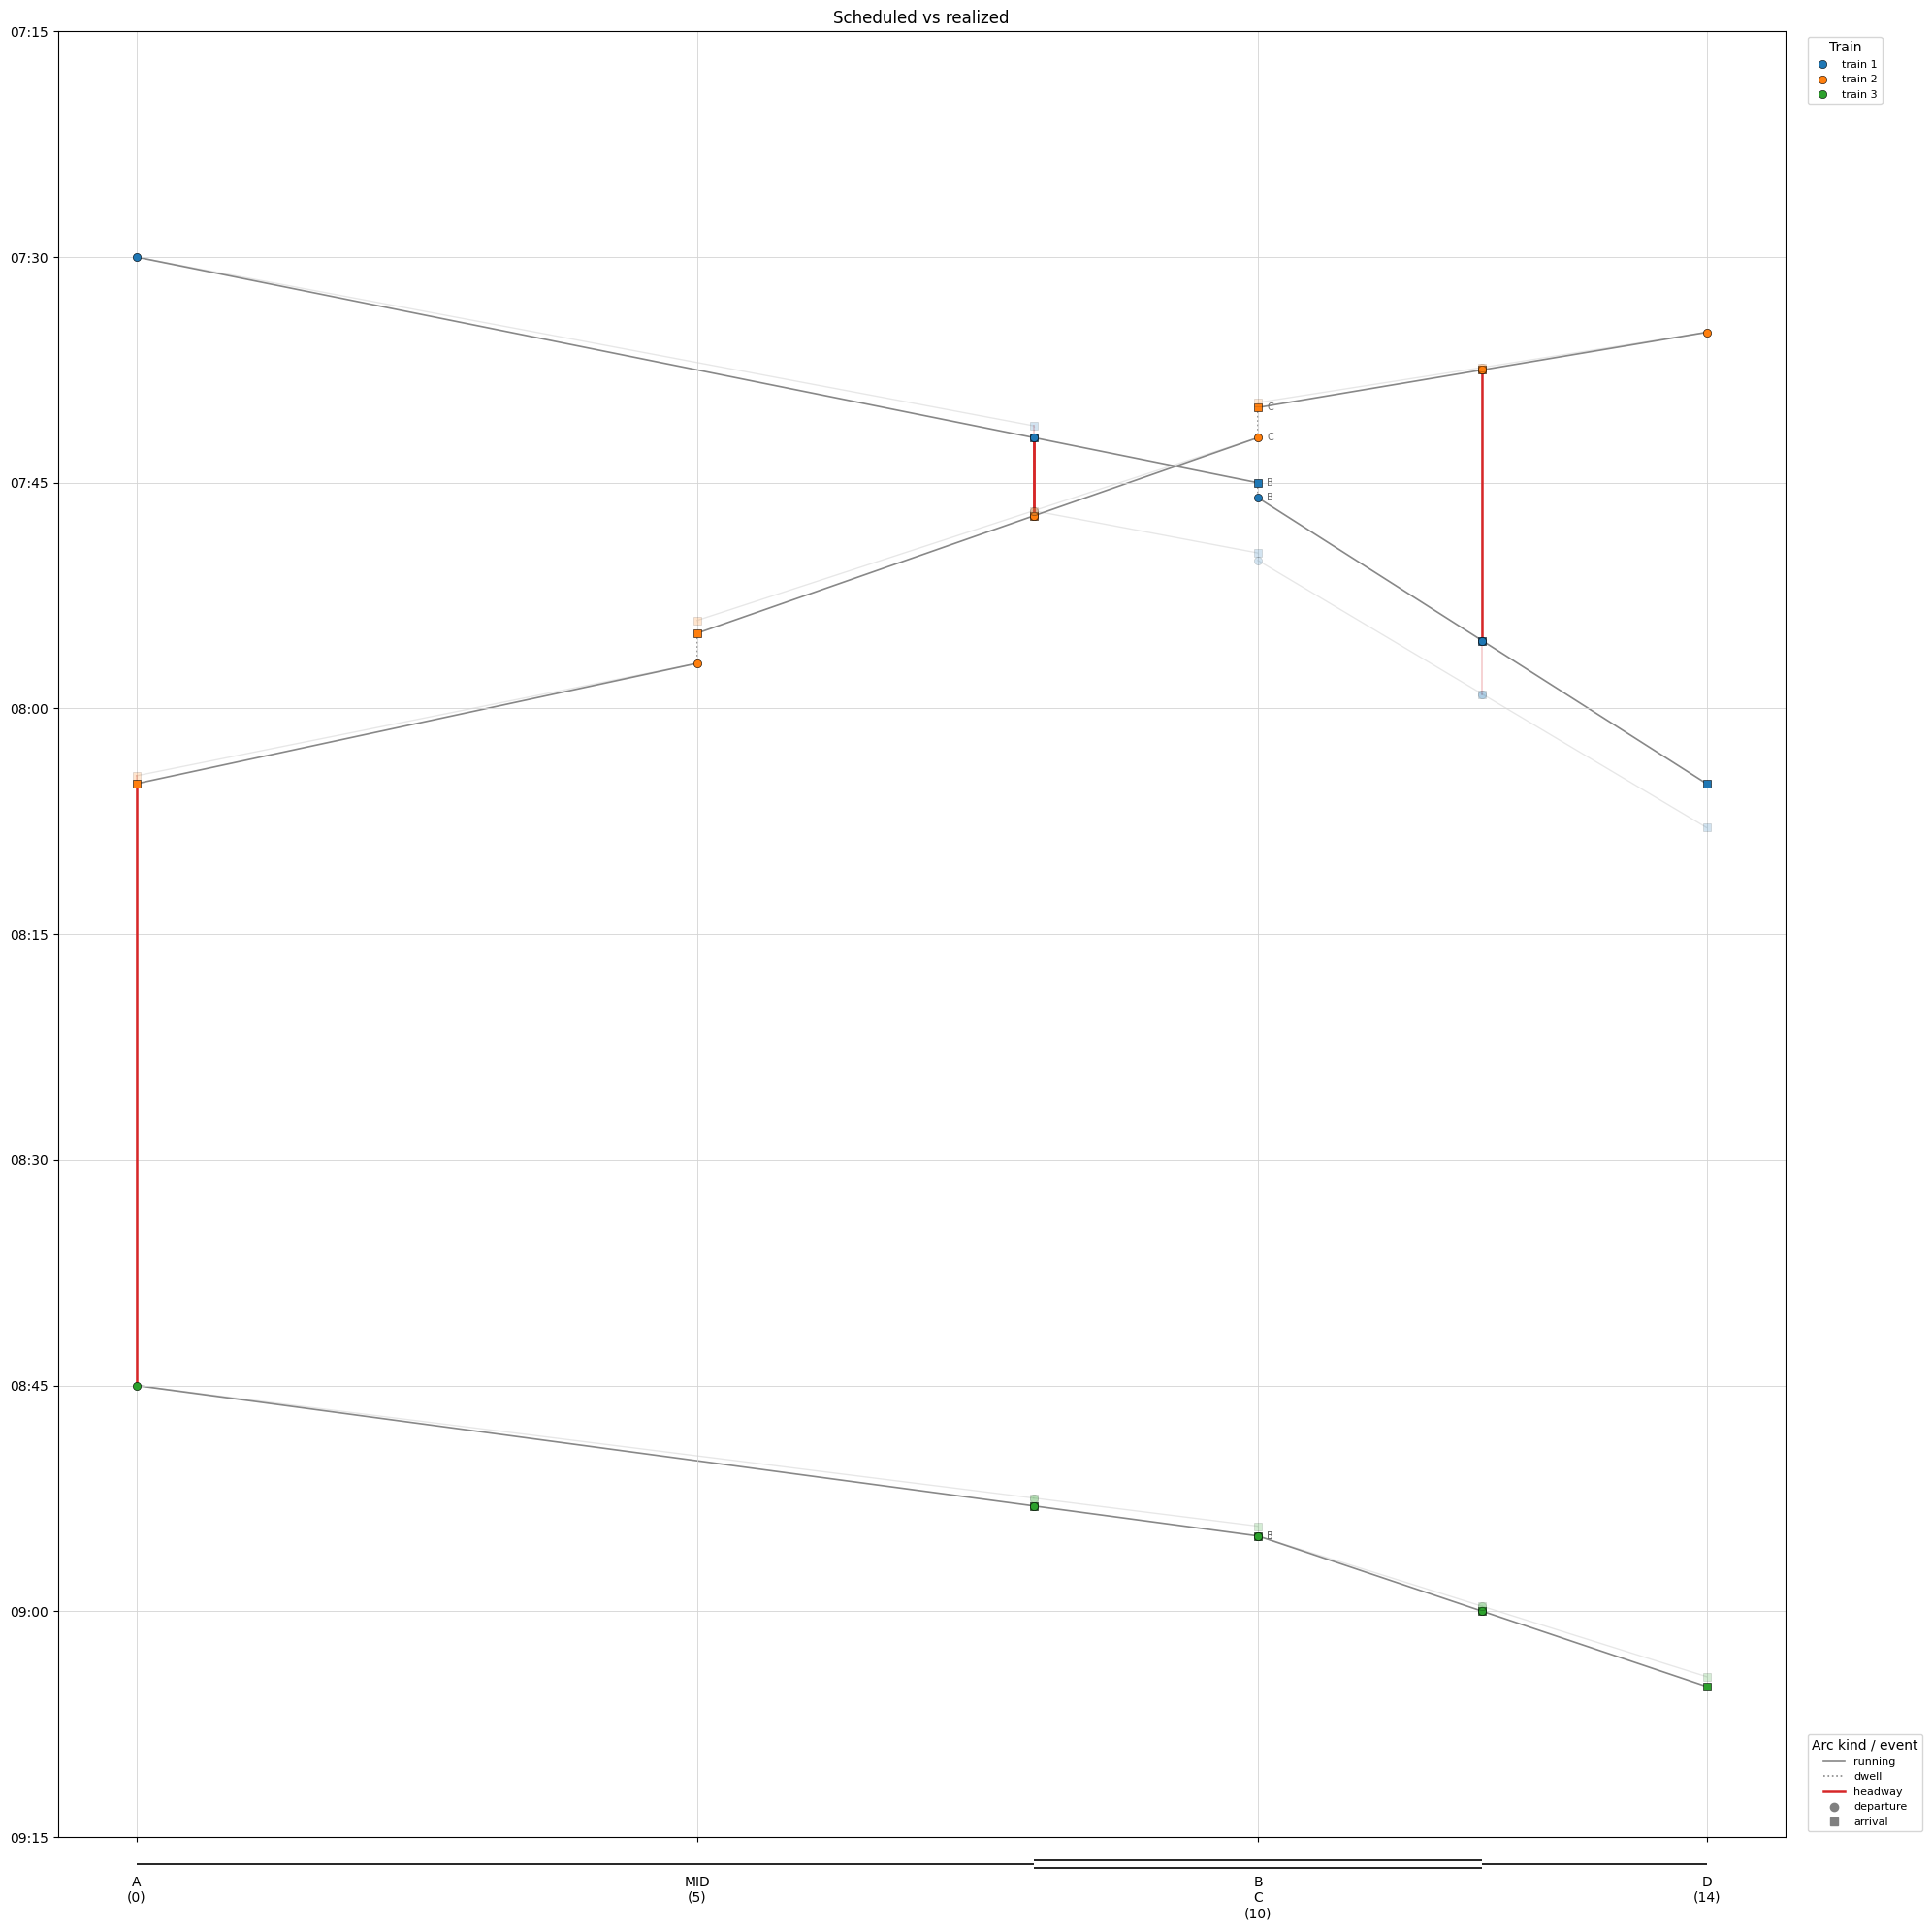

In [31]:
running_edges = [(u, v) for u, v, data in G_scheduled.edges(data=True) if data["kind"] == "running"]


#perturbations = [{},{edge: 60},{edge: 120},{edge: 300}]
perturbations = [{}]

realized_graphs = []

for p in perturbations:

    G_realized = propagate(G_scheduled, p)

    realized_graphs.append(G_realized)


fig, ax = viz.plot_ean(G_scheduled, nodesDf, edgesDf, title="Scheduled vs realized")

for G_realized in realized_graphs:
    viz.draw_ean(G_realized, nodesDf, ax, alpha=0.2, linewidth_scale=0.8)